In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
df = pd.read_csv("Pass-Fail Data.csv")
df.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


In [12]:
df.isnull().sum()
df.shape

(100, 6)

In [13]:
print(df.columns)

Index(['student_id', 'attendance_pct', 'homework_pct', 'midterm_score',
       'study_hours_per_week', 'pass'],
      dtype='object')


In [14]:
# Features and Target
x = df.drop(['student_id', 'pass'], axis=1)
y = df['pass']


In [15]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

In [16]:
from sklearn.tree import DecisionTreeClassifier , plot_tree

In [17]:
clf = DecisionTreeClassifier()

In [18]:
clf.fit(X_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
clf.score(X_test , y_test)

1.0

In [20]:
pred = clf.predict(X_test)

In [21]:
from sklearn.metrics import classification_report

In [22]:
print(classification_report(y_test , pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [23]:
import matplotlib.pyplot as plt

In [24]:
label = y.map({0 : 'yes' , 1 : 'no'}).unique()

In [25]:
label

array(['no', 'yes'], dtype=object)

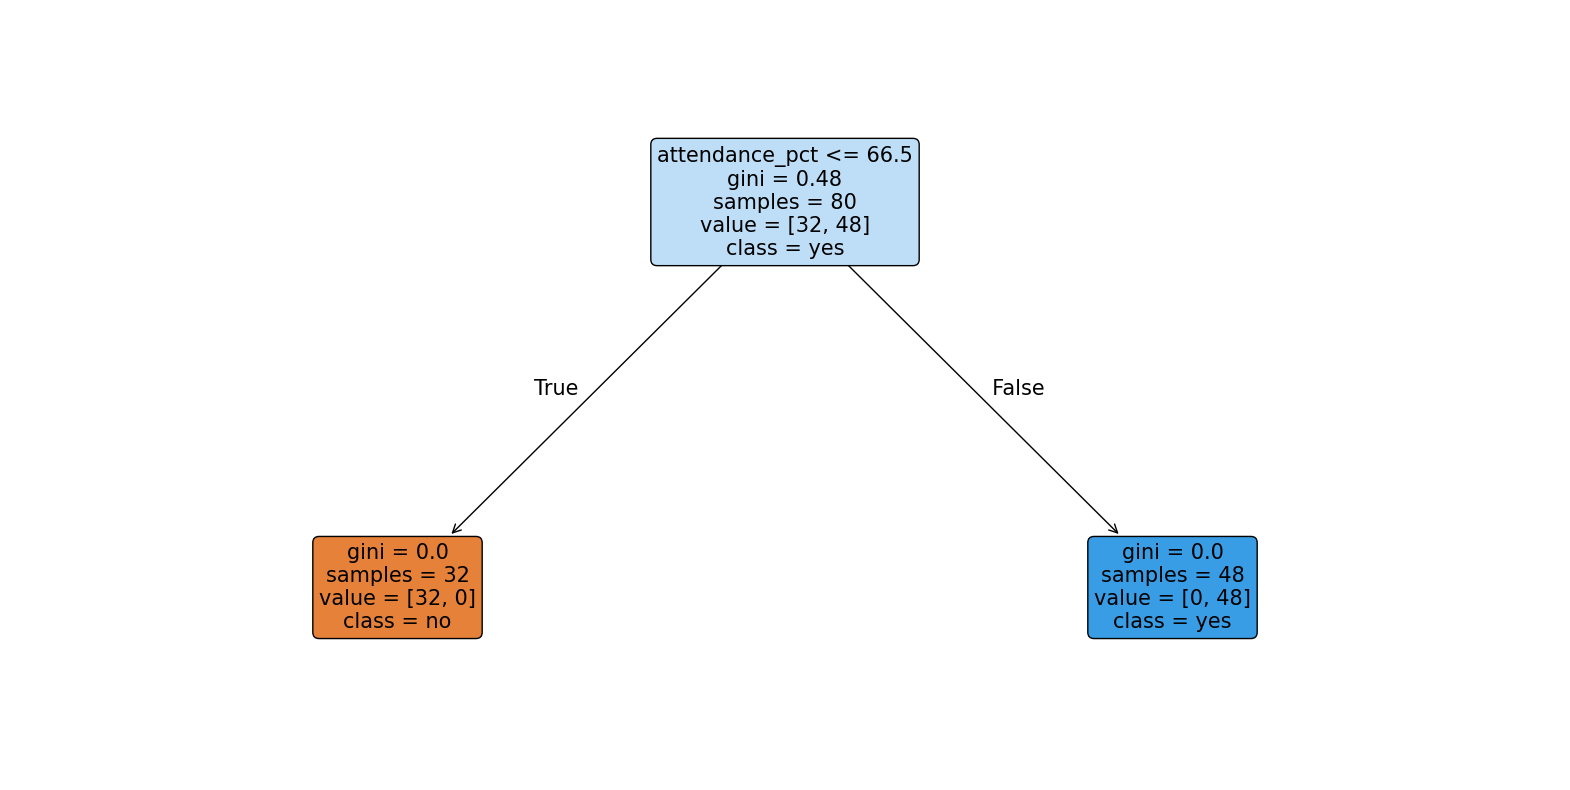

In [26]:
plt.figure(figsize = (20,10))
plot_tree(clf , feature_names= list(x.columns) , class_names=list(label) , rounded=True , filled=True , fontsize=15)
plt.show()